# Testing in Pilsen

In [30]:
from accessx.aoi import load_aoi, make_hex_grid
from accessx.graph import build_network, save_graph, load_graph
from accessx.cost import add_time_cost_constant_speed
from accessx.cost import add_slope_based_time, add_edge_cost
from accessx.poi import get_pois_osm
from accessx.isochrone import calculate_isochrones
from accessx.accessibility import count_accessible_pois, compute_nearest_poi_cost, compute_hansen_accessibility

from geopandas import read_file
import matplotlib.pyplot as plt

In [31]:
area_file = 'data/pilsen/area/castiobce.geojson'
city_epsg = 32633

data_path = 'data/pilsen/'


# Load Area and create Hex Grid

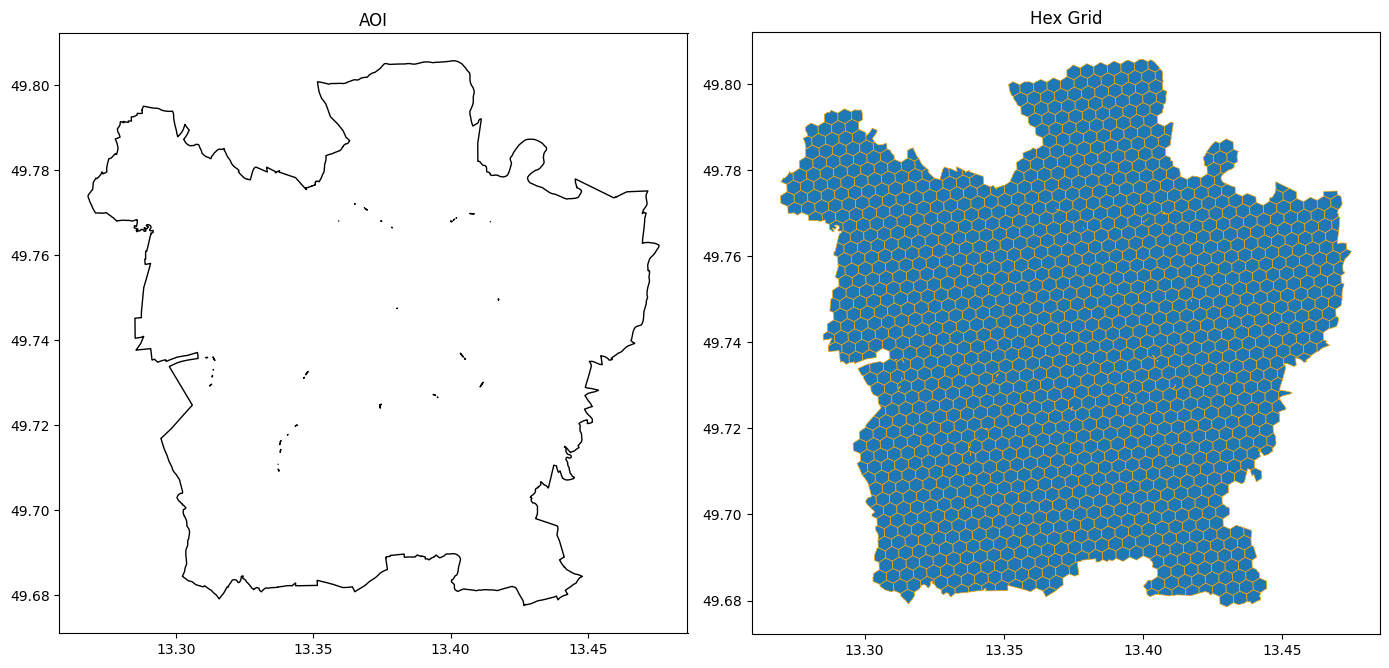

In [32]:

# # Municipality of Milano

#returns aoi in 4326
aoi = load_aoi(filepath=area_file, buffer_m=0, utm_crs=city_epsg, save_path= data_path + "area/aoi_pilsen.geojson")

# this calls H3's ppolyfill : “All H3 cell indexes whose centers fall inside the polygon.”
hexes = make_hex_grid(aoi,resolution=9, clip=True)
hexes_proj = hexes.to_crs(city_epsg)
hexes_proj.to_file(data_path + 'area/hexes_pilsen.geojson', driver="GeoJSON")


#plot

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

aoi.plot(ax=axes[0], facecolor="none", edgecolor="black")
axes[0].set_title("AOI")

hexes.plot(ax=axes[1], edgecolor="orange", linewidth=0.5)
axes[1].set_title("Hex Grid")

plt.tight_layout()
plt.show()

In [37]:
hexes.head()

,hex_id,geometry
0,891e30d1523ffff,"POLYGON ((13.33239 49.68282, 13.33476 49.68382..."
1,891e30d1527ffff,"POLYGON ((13.33724 49.68312, 13.33961 49.68412..."
2,891e30d0253ffff,"POLYGON ((13.34209 49.68342, 13.34446 49.68442..."
3,891e30d1537ffff,"POLYGON ((13.33949 49.68582, 13.33961 49.68412..."
4,891e30d02cbffff,"POLYGON ((13.34185 49.68682, 13.34434 49.68612..."


# Load Street Network

In [33]:
buffer=1000

G_proj = build_network(
    AOI=aoi,
    city_epsg=city_epsg,
    buffer_m=buffer,
    network_type="walk",
    simplify=False,
    retain_all=True,
)


save_graph(
    G_proj,
    out_dir= data_path + "street_network/",
    base_name="original_graph_pilsen",
    save_nodes=True,
    save_edges=True,
)

# Calculate cost per street segment (based on average walking speed)

In [34]:
# time-cost based on costant speed defined by the user
G_proj = add_time_cost_constant_speed(G_proj, speed_kmh=4.5, cost_col="avg_time")

save_graph(
    G_proj,
    out_dir= data_path + "street_network/",
    base_name="graph_with_cost_pilsen",
    save_nodes=True,
    save_edges=True,
)

# Calculate Isochrones

In [35]:
# read street network
G_proj = load_graph(
    nodes_path= data_path + "street_network/graph_with_cost_pilsen_nodes_OSM.geojson",
    edges_path= data_path + "/street_network/graph_with_cost_pilsen_edges_OSM.geojson",
    crs=city_epsg
)

# read hex-grid
hexes_proj = read_file( data_path + 'area/hexes_pilsen.geojson')

In [36]:
import os

gdf_hex = calculate_isochrones(
    G_proj,
    hexes_proj,
    max_cost=15,
    interval_size=3,
    cost_attr="avg_time",
    city_epsg=city_epsg,    
    max_distance=200,
    method="hull", # or hull
    n_jobs = os.cpu_count() - 1,
    edge_buff=25,
    infill=True,
    base_name = "walksheds_pilsen",
    save_dir=data_path + '/walksheds/',
)


/Users/vmlias/repos/accessX/src/accessx/isochrone.py:265: UserWarning: Geometry column does not contain geometry.
  out_csv["geometry"] = out_csv["geometry"].apply(lambda g: g.wkt if g is not None else None)
/Users/vmlias/repos/accessX/src/accessx/isochrone.py:265: UserWarning: Geometry column does not contain geometry.
  out_csv["geometry"] = out_csv["geometry"].apply(lambda g: g.wkt if g is not None else None)
/Users/vmlias/repos/accessX/src/accessx/isochrone.py:265: UserWarning: Geometry column does not contain geometry.
  out_csv["geometry"] = out_csv["geometry"].apply(lambda g: g.wkt if g is not None else None)
/Users/vmlias/repos/accessX/src/accessx/isochrone.py:265: UserWarning: Geometry column does not contain geometry.
  out_csv["geometry"] = out_csv["geometry"].apply(lambda g: g.wkt if g is not None else None)
/Users/vmlias/repos/accessX/src/accessx/isochrone.py:265: UserWarning: Geometry column does not contain geometry.
  out_csv["geometry"] = out_csv["geometry"].apply(lamb

In [38]:
gdf_hex.head()

,hex_id,geometry,geom_avg_time_3,geom_avg_time_6,geom_avg_time_9,geom_avg_time_12,geom_avg_time_15
0,891e30d1523ffff,"POLYGON ((379705.616 5504700.944, 379878.68 55...",None,None,None,None,None
1,891e30d1527ffff,"POLYGON ((380056.297 5504726.362, 380229.36 55...",None,None,None,None,None
2,891e30d0253ffff,"POLYGON ((380406.981 5504751.781, 380580.045 5...","POLYGON ((380695.1637409667 5504433.184563676,...","POLYGON ((380789.6258777312 5504230.634498023,...","POLYGON ((380876.0869599184 5504020.343061801,...","POLYGON ((380820.82312788843 5503849.38221987,...",POLYGON ((380947.1861997085 5503643.3315493325...
3,891e30d1537ffff,"POLYGON ((380224.803 5505023.631, 380229.36 55...",None,None,None,None,None
4,891e30d02cbffff,"POLYGON ((380397.864 5505131.192, 380575.484 5...",POLYGON ((380440.13706386584 5504818.693798337...,POLYGON ((380440.13706386584 5504818.693798337...,POLYGON ((380440.13706386584 5504818.693798337...,POLYGON ((380440.13706386584 5504818.693798337...,POLYGON ((381171.01006339537 5504663.742507230...


# Get POIs

In [31]:
tags_library = {
    # ############# Neighborhood services #############################
    "neighborhood_services": {
        "amenity": [
            "post_office",
            "bank", "atm",
            "community_centre", "social_facility", "social_centre",
            "police", "fire_station",
            "place_of_worship",
            "drinking_water", "water_point", "watering_place",
            "bar",
            "cafe", "ice_cream",
            "townhall",
        ],
        "shop": ["tobacco", "kiosk", "newsagent"],
        "place": ["square"],
    },

    # ############## Healthcare #############################
    "healthcare": {
        "amenity": ["hospital", "pharmacy", "clinic", "dentist", "doctor", "veterinary"],
        "emergency": True,  # any emergency=*
    },

    # ############# Neighbourhood shops #############################
    "neighbourhood_shops": {
        "shop": [
            "grocery", "supermarket", "convenience",
            "greengrocer", "butcher", "dairy", "bakery",
            "general", "variety_store",
            "books",
            "electronics", "clothes", "shoes",
        ],
        "amenity": [
            "vending_machine",
            "toy_library",
            "marketplace",
            "restaurant", "fast_food", "food_court",
        ],
    },

    # ############# Education #############################
    "education": {
        "amenity": [
            "kindergarten", "childcare",
            "school",
            "university", "college", "research_institute",
            "music_school", "language_school", "first_aid_school",
            "training", "driving_school", "dancing_school",
            "library", "public_bookcase",
        ],
    },

    # ############# Sports #############################
    "sports": {
        "leisure": ["fitness_centre", "fitness_station", "sports_centre", "sports_hall"],
        "sport": ["gymnastics", "swimming"],
    },

    # ############# Cultural & entertainment #############################
    "cultural": {
        "amenity": ["cinema", "theatre", "arts_centre"],
        "tourism": ["museum"],
    },

    # ############# Open Leisure #############################
    "open_leisure": {
        "leisure": ["park", "playground", "dog_park", "garden"],
        "amenity": ["bbq"],
    },

    # ############# Mobility #############################
    "mobility": {
        "highway": ["bus_stop"],
        "railway": ["tram_stop", "subway_entrance", "station", "halt"],
        "amenity": ["bicycle_parking", "bicycle_rental", "car_sharing", "taxi"],
    },
}


In [32]:
pois = get_pois_osm(aoi, tags_library=tags_library, categories=["neighborhood_services", 
                                     "healthcare",
                                     "neighbourhood_shops", 
                                     "education",
                                     "sports",
                                     "cultural",
                                     "open_leisure",
                                     "mobility"
                                    ])

/Users/vmlias/repos/accessX/env_accessx/lib/python3.12/site-packages/geopandas/geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)


In [36]:
pois.to_file(data_path + 'pois/pois.geojson', driver="GeoJSON")
pois.head()

,id,osmid,name,osm_type,category,geometry
0,0,273724231,Česká spořitelna,node,neighborhood_services,POINT (13.36934 49.77894)
1,1,273735898,Shell,node,neighborhood_services,POINT (13.37278 49.75779)
2,2,273741654,NaN,node,neighborhood_services,POINT (13.34373 49.72855)
3,3,274615055,Jazz rock café,node,neighborhood_services,POINT (13.37556 49.74756)
4,4,275636807,Česká spořitelna,node,neighborhood_services,POINT (13.36814 49.77571)


# Estimate Accessibility Scores

## READ DATA NEEDED

In [23]:
# read street network
G_proj = load_graph(
    nodes_path= data_path + "/street_network/graph_with_cost_pilsen_nodes_OSM.geojson",
    edges_path= data_path + "/street_network/graph_with_cost_pilsen_edges_OSM.geojson",
    crs=city_epsg
)

# read hex-grid
hexes_proj = read_file(data_path + '/area/hexes_pilsen.geojson')

pois = read_file(data_path + '/pois/pois.geojson')


In [24]:
gdf_access_nearest = compute_nearest_poi_cost(G_proj, 
                                              hexes_proj, 
                                              pois, 
                                              max_cost=15, 
                                              poi_id_col='osmid', 
                                              cost_attr="avg_time", 
                                              number_of_nearest=1,
                                              output="long", #, "long", "wide"
                                              max_distance_from_graph=200)

In [28]:
gdf_access_nearest.head(3)

,hex_id,category,rank,cost,osmid
0,891e30d02cbffff,mobility,1,8.969926,10712366836
1,891e30d02cfffff,mobility,1,5.380368,10712366836
2,891e30d15afffff,open_leisure,1,14.577890,131572321


In [25]:
gdf_hansen = compute_hansen_accessibility(
    graph=G_proj,
    hexes=hexes_proj,
    pois=pois,
    max_cost=15,
    cost_attr="avg_time",
    id_col="hex_id",
    category_col="category",
    # poi_weight_col="capacity",  # per-POI weight column
    default_poi_weight=1.0,
        # category_weights={          # per-category multipliers
    #     "neighborhood_services": 1.5,
    #     "mobility": 1.2,
    #     "shop": 1.0,
    # },
    beta=0.2,
    max_distance_from_graph=200.0,
)

gdf_hansen.to_file(data_path + 'accessibility/hansen.geojson', driver='GeoJSON')

In [27]:
gdf_access_count = count_accessible_pois(G_proj, 
                                         hexes_proj, 
                                         pois, 
                                         max_cost=15, 
                                         cost_attr="avg_time",
                                         max_distance_from_graph=200)


gdf_access_count.to_file(data_path + 'accessibility/counts.geojson', driver='GeoJSON')

In [29]:
gdf_hansen

,hex_id,geometry,hansen_cultural,hansen_education,hansen_healthcare,hansen_mobility,hansen_neighborhood_services,hansen_neighbourhood_shops,hansen_open_leisure,hansen_sports,hansen_total
0,891e30d1523ffff,"POLYGON ((379705.616 5504700.944, 379878.68 55...",0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000
1,891e30d1527ffff,"POLYGON ((380056.297 5504726.362, 380229.36 55...",0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000
2,891e30d0253ffff,"POLYGON ((380406.981 5504751.781, 380580.045 5...",0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000
3,891e30d1537ffff,"POLYGON ((380224.803 5505023.631, 380229.36 55...",0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000
4,891e30d02cbffff,"POLYGON ((380397.864 5505131.192, 380575.484 5...",0.0,0.0,0.0,0.323483,0.0,0.0,0.0,0.0,0.323483
...,...,...,...,...,...,...,...,...,...,...,...
1379,891e346d0c3ffff,"POLYGON ((385017.421 5517430.27, 385012.818 55...",0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000
1380,891e346d0d3ffff,"POLYGON ((384830.679 5517891.105, 385003.614 5...",0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000
1381,891e346d0d7ffff,"POLYGON ((385363.298 5517645.18, 385185.755 55...",0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000
1382,891e346d46bffff,"POLYGON ((384999.012 5518187.975, 385003.614 5...",0.0,0.0,0.0,0.174620,0.0,0.0,0.0,0.0,0.174620
